# Sparse vs Dense Scaling

**Model.** This notebook compares dense and sparse matrix construction for selected tight-binding and Hubbard builders. Sparse matrices store only nonzero entries and are useful for low-energy calculations.

**Typical uses.** Memory-scaling checks, deciding when to switch to sparse workflows, low-energy spectra with `eigsh`, and sanity checks that sparse and dense builders agree.

**Parameters.** `n_sites`, `n_rows`, `n_cols`, and `max_occupancy` drive dimension growth. `nnz` counts sparse nonzero entries. `lowest_eigenvalues(H, k)` computes low-energy values with sparse solvers for sparse matrices.

**Useful plots.** Sparse density and storage comparisons, sparse/dense eigenvalue agreement, and low-energy spectra.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import (
    bose_hubbard_chain,
    bose_hubbard_chain_sparse,
    fermi_hubbard_chain,
    fermi_hubbard_chain_sparse,
    square_lattice_tight_binding,
    square_lattice_tight_binding_sparse,
)
from quantum_lattice_models.spectra import eigenvalues, lowest_eigenvalues

In [2]:
comparisons = []
for n in [2, 3, 4]:
    dense = bose_hubbard_chain(n_sites=n, max_occupancy=2)
    sparse = bose_hubbard_chain_sparse(n_sites=n, max_occupancy=2)
    sparse_bytes = sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes
    comparisons.append(
        (
            f"Bose n={n}",
            dense.shape[0],
            sparse.nnz,
            sparse.nnz / dense.size,
            dense.nbytes / sparse_bytes,
        )
    )
for n in [2, 3]:
    dense = fermi_hubbard_chain(n_sites=n)
    sparse = fermi_hubbard_chain_sparse(n_sites=n)
    sparse_bytes = sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes
    comparisons.append(
        (
            f"Fermi n={n}",
            dense.shape[0],
            sparse.nnz,
            sparse.nnz / dense.size,
            dense.nbytes / sparse_bytes,
        )
    )
for rows, cols in [(4, 4), (6, 6)]:
    dense = square_lattice_tight_binding(rows, cols)
    sparse = square_lattice_tight_binding_sparse(rows, cols)
    comparisons.append(
        (
            f"Square {rows}x{cols}",
            dense.shape[0],
            sparse.nnz,
            sparse.nnz / dense.size,
            dense.nbytes / (sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes),
        )
    )

print("model          | dimension | nonzeros | sparse density | dense/sparse bytes")
print("---            | ---       | ---      | ---            | ---")
for label, dimension, nnz, density, storage_ratio in comparisons:
    print(
        f"{label:<14s} | {dimension:>9d} | {nnz:>8d} | "
        f"{density:.4f}         | {storage_ratio:>6.2f}x"
    )

model          | dimension | nonzeros | sparse density | dense/sparse bytes
---            | ---       | ---      | ---            | ---
Bose n=2       |         9 |       13 | 0.1605         |   4.32x
Bose n=3       |        27 |       67 | 0.0919         |   8.03x
Bose n=4       |        81 |      281 | 0.0428         |  17.65x
Fermi n=2      |        16 |       23 | 0.0898         |   7.76x
Fermi n=3      |        64 |      165 | 0.0403         |  18.41x
Square 4x4     |        16 |       48 | 0.1875         |   3.98x
Square 6x6     |        36 |      120 | 0.0926         |   8.14x


In [3]:
dense = square_lattice_tight_binding(3, 3)
sparse = square_lattice_tight_binding_sparse(3, 3)
dense_lowest = eigenvalues(dense)[:4]
sparse_lowest = lowest_eigenvalues(sparse, k=4)
print("Square 3x3 lowest eigenvalues")
print("  dense: ", np.array2string(dense_lowest, precision=6, separator=", "))
print("  sparse:", np.array2string(sparse_lowest, precision=6, separator=", "))

Square 3x3 lowest eigenvalues
  dense:  [-2.828427e+00, -1.414214e+00, -1.414214e+00, -1.737460e-16]
  sparse: [-2.828427e+00, -1.414214e+00, -1.414214e+00, -8.133100e-17]


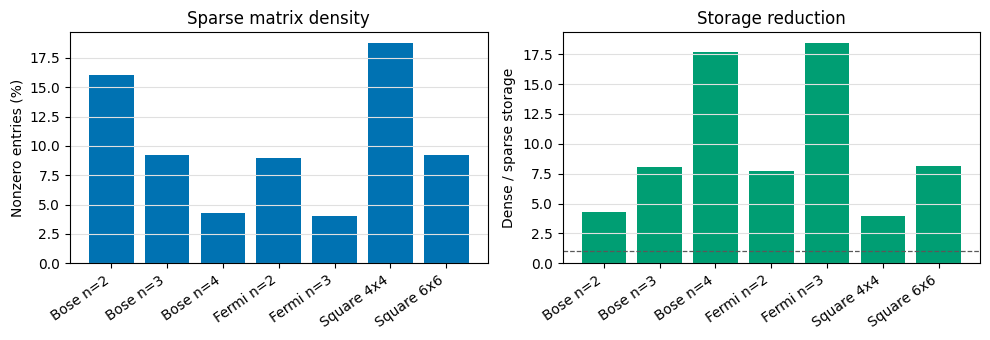

In [4]:
labels = [row[0] for row in comparisons]
densities = [100 * row[3] for row in comparisons]
storage_ratios = [row[4] for row in comparisons]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
x = np.arange(len(labels))
axes[0].bar(x, densities, color="#0072B2")
axes[0].set_ylabel("Nonzero entries (%)")
axes[0].set_title("Sparse matrix density")
axes[1].bar(x, storage_ratios, color="#009E73")
axes[1].axhline(1.0, color="0.35", linestyle="--", linewidth=0.9)
axes[1].set_ylabel("Dense / sparse storage")
axes[1].set_title("Storage reduction")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="y", color="0.88", linewidth=0.8)
fig.tight_layout()